# CNN 2 Classification: 3s / 25 Segments, augmented

This notebook trains and evaluates the second CNN variant using MFCC matrices extracted from 25 random 3-second segments per track.

The model uses MFCC segment matrices as input and is evaluated on both segment level and track level. Track-level predictions are derived by aggregating the segment-level predictions of each track.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras import Sequential
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from sklearn.model_selection import train_test_split
import os
from src.config import (
    MFCC_MATRIX_TRAIN_PKL,
    MFCC_MATRIX_VAL_PKL,
    MFCC_MATRIX_TEST_PKL,
    TRAINED_MODELS_DIR,
    MODEL_RESULTS_DIR,
    RANDOM_STATE,
    PROCESSED_TRACKS_CSV
)

In [2]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# General
VERBOSE = 1
MODEL_NAME = "CNN2_3s_25_aug"

# Dataset
NORMALIZE_FEATURES = True
REDUCTION_FACTOR = 1        # Percentage of training data to keep

# Training
BATCH_SIZE = [32]
EPOCHS = [60]
MIN_LEARNING_RATE = 1e-6
LEARNING_RATE = 3e-4

In [ ]:
# Read in pkl-Files which contain mfccs
df_features_tracks_train = pd.read_pickle(MFCC_MATRIX_TRAIN_PKL)
df_features_tracks_val = pd.read_pickle(MFCC_MATRIX_VAL_PKL)
df_features_tracks_test = pd.read_pickle(MFCC_MATRIX_TEST_PKL)

In [ ]:
# Read in metadata
tracks = pd.read_csv(PROCESSED_TRACKS_CSV)
tracks = tracks[["track_id", "track_genre_top"]]

In [8]:
# ---------------------------------------------------------
# FEATURE NORMALIZATION
# ---------------------------------------------------------

# Stack the feature arrays from the DataFrame into 3D NumPy arrays
# Shape: (num_samples, time_steps, num_features)
X_train = np.stack(df_features_tracks_train["X"].values)
X_val   = np.stack(df_features_tracks_val["X"].values)
X_test  = np.stack(df_features_tracks_test["X"].values)


if NORMALIZE_FEATURES:
    print("Applying feature normalization...")

    # Compute mean and standard deviation from TRAINING data only
    # Mean and std are calculated across samples and time dimensions
    # keepdims=True ensures correct broadcasting
    mu = X_train.mean(axis=(0, 1), keepdims=True)
    sigma = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

    # Normalize all dataset splits using training statistics
    # This prevents data leakage
    X_train = (X_train - mu) / sigma
    X_val   = (X_val   - mu) / sigma
    X_test  = (X_test  - mu) / sigma

    # Store normalized data
    df_features_tracks_train["X_used"] = list(X_train)
    df_features_tracks_val["X_used"]   = list(X_val)
    df_features_tracks_test["X_used"]  = list(X_test)

else:
    print("Skipping feature normalization...")

    # Use raw features
    df_features_tracks_train["X_used"] = df_features_tracks_train["X"]
    df_features_tracks_val["X_used"]   = df_features_tracks_val["X"]
    df_features_tracks_test["X_used"]  = df_features_tracks_test["X"]

Applying feature normalization...


In [9]:
# Check total sample count per genre for trainingsset
df_features_tracks_train['track_genre_top'].value_counts()

track_genre_top
Classical              53375
Electronic             53375
Folk                   53375
Hip-Hop                53375
Jazz                   53375
Old-Time / Historic    53375
Pop                    53375
Rock                   53375
Name: count, dtype: int64

In [10]:
# Create a LabelEncoder instance
# This converts categorical genre labels into numeric class indices
label_encoder = LabelEncoder()

# Collect all labels from train, validation, and test sets
# This ensures that the encoder knows every possible class
all_labels = (
    list(df_features_tracks_train["track_genre_top"]) +
    list(df_features_tracks_val["track_genre_top"]) +
    list(df_features_tracks_test["track_genre_top"])
)

# Fit the encoder on all available labels
# Each unique genre will be mapped to an integer (e.g., Rock -> 0, Jazz -> 1, etc.)
label_encoder.fit(all_labels)

LabelEncoder()

In [ ]:
# Convert string labels → integer labels
y_train = label_encoder.transform(df_features_tracks_train["track_genre_top"])
y_val   = label_encoder.transform(df_features_tracks_val["track_genre_top"])
y_test  = label_encoder.transform(df_features_tracks_test["track_genre_top"])

# Optional: Reduce training set
if REDUCTION_FACTOR < 1:
    X_train_reduced, _, y_train_reduced, _ = train_test_split(
        X_train,
        y_train,
        train_size=REDUCTION_FACTOR,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    X_train_reduced = X_train
    y_train_reduced = y_train

print(f"X_train shape: {X_train_reduced.shape}")
print(f"y_train shape: {y_train_reduced.shape}")
print(f"Number of genres: {len(label_encoder.classes_)}")

X_train shape: (427000, 259, 20)
y_train shape: (427000,)
Number of genres: 8


In [12]:
def build_cnn(input_shape, num_classes):
    """
    Builds a CNN model for genre classification.

    Architecture:
    - 3 convolutional blocks with BatchNorm + ReLU
    - Progressive filter increase (32 → 64 → 128)
    - Different kernel sizes for local and broader temporal patterns
    - MaxPooling after each convolutional block for temporal downsampling
    - GlobalAveragePooling instead of Flatten
    - Two Dense layers with Dropout for regularization
    - Softmax output for multi-class classification
    """

    model = Sequential([
        Conv1D(
            32,
            3,
            activation='relu',
            padding="same",
            input_shape=(input_shape)
        ),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(64, 3, activation='relu', padding="same"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 5, activation='relu', padding="same"),
        BatchNormalization(),
        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(256, activation='relu'),
        Dropout(0.5),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def run_experiments(X_train, y_train,
                    X_val, y_val,
                    X_test, y_test,
                    input_shape,
                    num_classes,
                    label_encoder):

    """
    Runs training experiments with different hyperparameters.
    
    Includes:
    - EarlyStopping
    - Learning rate reduction on plateau
    - Validation & Test evaluation
    - Accuracy/Loss visualization
    - Metric logging
    """
    epochs_list = EPOCHS
    batch_sizes = BATCH_SIZE

    results = {}

    # Stop training if validation loss does not improve
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
   
    # Reduce learning rate when validation loss plateaus
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=MIN_LEARNING_RATE,
        verbose=VERBOSE
    )

    for batch_size in batch_sizes:
        for epochs in epochs_list:

            print(f"\n Training with {epochs} epochs, batch size {batch_size}")

            # Build a fresh model for each experiment
            model = build_cnn(input_shape, num_classes)

            # ---------------------------------------------------
            # COMPILE THE MODEL
            # ---------------------------------------------------
            model.compile(optimizer=tf.keras.optimizers.AdamW(
                            learning_rate=LEARNING_RATE,
                            weight_decay=1e-5
                            ), 
                            loss= tf.keras.losses.SparseCategoricalCrossentropy(),
                            metrics=['accuracy'])

            # ---------------------------------------------------
            # TRAIN THE MODEL
            # ---------------------------------------------------
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop, reduce_lr],
                verbose=VERBOSE
            )

            # ---------------------------------------------------
            # VALIDATION EVALUATION
            # ---------------------------------------------------
            y_pred_prob = model.predict(X_val)
            y_pred = np.argmax(y_pred_prob, axis=1)
            y_true = y_val

            # Recreate labels
            class_names = label_encoder.classes_
            class_names_str = [str(c) for c in class_names]

            print("\n--- VALIDATION REPORT ---")
            print("Accuracy:", accuracy_score(y_true, y_pred))
            print("\nClassification Report:")
            print(classification_report(y_true, y_pred, target_names=class_names_str))
            print("\nConfusion Matrix:")
            print(confusion_matrix(y_true, y_pred))

            # ---------------------------------------------------
            # TEST EVALUATION
            # ---------------------------------------------------
            y_pred_prob = model.predict(X_test)
            y_pred = np.argmax(y_pred_prob, axis=1)
            y_true = y_test

            print("\n--- FINAL TEST REPORT ---")
            print("Accuracy:", accuracy_score(y_true, y_pred))
            print("\nClassification Report:")
            print(classification_report(y_true, y_pred, target_names=class_names_str))
            print("\nConfusion Matrix:")
            print(confusion_matrix(y_true, y_pred))

            # ---------------------------------------------------
            # PLOT TRAINING CURVES
            # ---------------------------------------------------
            fig, ax = plt.subplots(1, 2, figsize=(14, 5))

            # Accuracy plot
            ax[0].plot(history.history['accuracy'], label='Train Accuracy')
            ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
            ax[0].set_title(f'Accuracy (epochs={epochs}, batch={batch_size})')
            ax[0].set_xlabel('Epoch')
            ax[0].set_ylabel('Accuracy')
            ax[0].legend()

            # Loss plot
            ax[1].plot(history.history['loss'], label='Train Loss')
            ax[1].plot(history.history['val_loss'], label='Val Loss')
            ax[1].set_title(f'Loss (epochs={epochs}, batch={batch_size})')
            ax[1].set_xlabel('Epoch')
            ax[1].set_ylabel('Loss')
            ax[1].legend()

            plt.show()

            # ---------------------------------------------------
            # STORE EXPERIMENT RESULTS
            # ---------------------------------------------------
            key = f"epochs={epochs}_batch={batch_size}"

            # Mean validation metrics
            result_entry = {
                metric: float(np.mean(values))
                for metric, values in history.history.items()
            }

            # Best validation metrics
            result_entry.update({
                "best_val_accuracy": float(np.max(history.history.get("val_accuracy", [None]))),
                "best_val_loss": float(np.min(history.history.get("val_loss", [None]))),
            })

            # Final train metrics
            result_entry.update({
                "final_train_accuracy": float(history.history.get("accuracy", [None])[-1]),
                "final_train_loss": float(history.history.get("loss", [None])[-1]),
            })

            # EarlyStopping
            if "early_stopping" in locals() or "early_stopping" in globals():
                try:
                    best_epoch = early_stop.best_epoch
                    result_entry.update({
                        "early_stopping_epoch": int(best_epoch),
                        "early_stopping_val_accuracy": float(history.history["val_accuracy"][best_epoch]),
                        "early_stopping_val_loss": float(history.history["val_loss"][best_epoch]),
                    })
                except:
                    pass

            
            results[key] = result_entry
    
    # Save final trained model
    model.save(f"{TRAINED_MODELS_DIR}/{MODEL_NAME}.keras")
    return model, results


 Training with 60 epochs, batch size 32


j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 171s 12ms/step - accuracy: 0.5566 - loss: 1.2390 - val_accuracy: 0.6476 - val_loss: 1.0018 - learning_rate: 3.0000e-04
Epoch 2/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 190s 14ms/step - accuracy: 0.6486 - loss: 0.9967 - val_accuracy: 0.6622 - val_loss: 0.9995 - learning_rate: 3.0000e-04
Epoch 3/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 263s 20ms/step - accuracy: 0.6939 - loss: 0.8732 - val_accuracy: 0.6602 - val_loss: 1.0651 - learning_rate: 3.0000e-04
Epoch 4/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 393s 29ms/step - accuracy: 0.7235 - loss: 0.7911 - val_accuracy: 0.6623 - val_loss: 1.1556 - learning_rate: 3.0000e-04
Epoch 5/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 379s 28ms/step - accuracy: 0.7449 - loss: 0.7331 - val_accuracy: 0.6602 - val_loss: 1.1731 - learning_rate: 3.0000e-04
Epoch 6/60
13344/13344 ━━━━━━━━━━━━━━━━━━━━ 383s 29ms/step - accuracy: 0.7602 - loss: 0.6918 - val_accuracy: 0.6673 - val_loss: 1.1988 - learning_rate: 3.0000e-04
Epoch 7/60
13344/13344

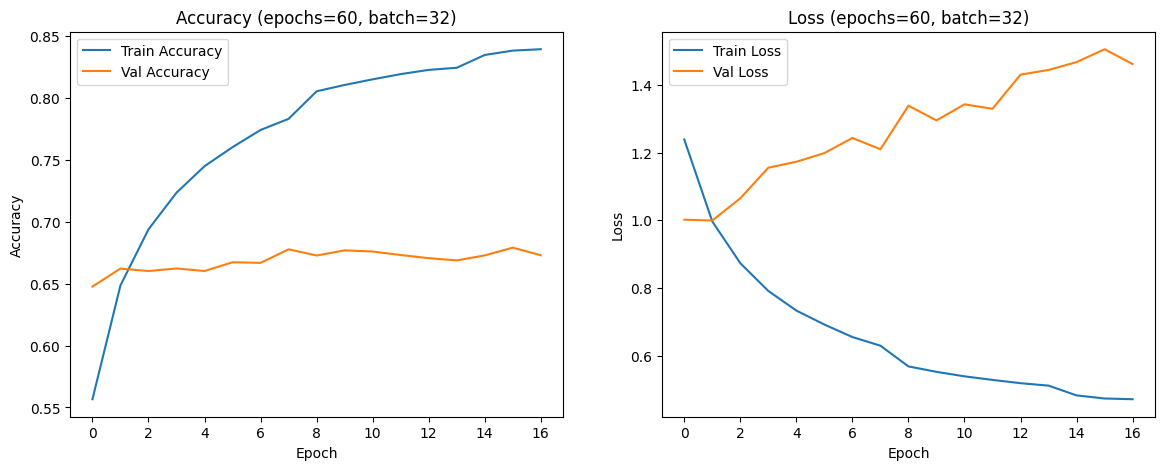

In [14]:
# List to collect results from all experiments
all_results = []

# Define the input shape:
# (time_steps, num_features)        
input_shape = (X_train.shape[1], X_train.shape[2])

# Number of output classes (from one-hot encoded labels)
num_classes = len(label_encoder.classes_)


# Run the experiment (training + validation + test evaluation)
model, results = run_experiments(
    X_train_reduced, y_train_reduced,
    X_val, y_val,
    X_test, y_test,
    input_shape, num_classes,
    label_encoder
)

# Example: retrieve average accuracy if stored inside results
avg_acc = results.get("avg_accuracy", None)


# Store experiment metadata and results
all_results.append({

    # Average samples per class (based on label distribution)
    "n_train": len(y_train_reduced) / num_classes,
    "n_val": len(y_val) / num_classes,
    "n_test": len(y_test) / num_classes,

    # Total dataset sizes
    "train_shape": len(X_train),
    "val_shape": len(X_val),
    "test_shape": len(X_test),

    # Store experiment metrics
    **results
})
    

In [15]:
# Print results
print(all_results)

[{'n_train': 53375.0, 'n_val': 1325.0, 'n_test': 1325.0, 'train_shape': 427000, 'val_shape': 10600, 'test_shape': 10600, 'epochs=60_batch=32': {'accuracy': 0.770253623233122, 'loss': 0.6618776338941911, 'val_accuracy': 0.6686514966628131, 'val_loss': 1.274479157784406, 'learning_rate': 0.0002073529510252068, 'best_val_accuracy': 0.6790565848350525, 'best_val_loss': 0.9994667768478394, 'final_train_accuracy': 0.839341938495636, 'final_train_loss': 0.47098657488822937}}]


In [ ]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------

# Generate predicted class probabilities for the test set
y_pred_probs = model.predict(X_test)

# Convert predicted probabilities to class indices
# (take the class with highest probability)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

y_true_labels = y_test

# ----- Create analysis DataFrame -----

# Create a copy of the original test DataFrame
# This ensures the original data remains unchanged
analysis_df = df_features_tracks_test.copy()

# Convert numeric class indices back to original genre labels (strings)
analysis_df['true_genre'] = label_encoder.inverse_transform(y_true_labels)
analysis_df['predicted_genre'] = label_encoder.inverse_transform(y_pred_labels)

# ----- Identify misclassified samples -----

# Filter rows where prediction does not match the true label
misclassified = analysis_df[analysis_df['true_genre'] != analysis_df['predicted_genre']]

# Print misclassification DataFrame
print(misclassified[['track_id', 'true_genre', 'predicted_genre']])

332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
      track_id true_genre predicted_genre
150     149702  Classical      Electronic
152     149702  Classical            Folk
153     149702  Classical            Folk
154     149702  Classical            Folk
155     149702  Classical            Folk
...        ...        ...             ...
10594   001287       Rock            Jazz
10595   001287       Rock             Pop
10596   001287       Rock      Electronic
10597   001287       Rock      Electronic
10599   001287       Rock             Pop

[4029 rows x 3 columns]


In [ ]:
# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION
# ---------------------------------------------------------

# This cell aggregates the 25 segment predictions of each track into one
# final prediction per track. This avoids counting one track multiple times
# in the final evaluation.

class_names = label_encoder.classes_
class_names_str = [str(c) for c in class_names]

# Use the prediction probabilities from the previous cell if available.
# Otherwise, generate them here.
if "y_pred_probs" not in globals():
    if "X_test_cnn" in globals():
        y_pred_probs = model.predict(X_test_cnn)
    else:
        y_pred_probs = model.predict(X_test)

# Segment-level predictions
segment_pred_labels = np.argmax(y_pred_probs, axis=1)
segment_true_labels = y_test

# Create a complete segment-level analysis DataFrame
# Important: this contains correct and incorrect segment predictions.
segment_analysis_df = df_features_tracks_test.copy().reset_index(drop=True)
segment_analysis_df["true_label"] = segment_true_labels
segment_analysis_df["predicted_label"] = segment_pred_labels
segment_analysis_df["true_genre"] = label_encoder.inverse_transform(segment_true_labels)
segment_analysis_df["predicted_genre"] = label_encoder.inverse_transform(segment_pred_labels)

# Add class probabilities to the analysis DataFrame
prob_cols = [f"prob_{genre}" for genre in class_names_str]
prob_df = pd.DataFrame(y_pred_probs, columns=prob_cols)
segment_analysis_df = pd.concat([segment_analysis_df, prob_df], axis=1)

# ---------------------------------------------------------
# SEGMENT-LEVEL REPORT
# ---------------------------------------------------------

print("\n--- SEGMENT-LEVEL TEST REPORT ---")
print("Accuracy:", accuracy_score(segment_analysis_df["true_label"], segment_analysis_df["predicted_label"]))
print("Macro-F1:", f1_score(segment_analysis_df["true_label"], segment_analysis_df["predicted_label"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    segment_analysis_df["true_label"],
    segment_analysis_df["predicted_label"],
    target_names=class_names_str
))
print("\nConfusion Matrix:")
print(confusion_matrix(segment_analysis_df["true_label"], segment_analysis_df["predicted_label"]))

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION 1: MAJORITY VOTING
# ---------------------------------------------------------

# For each track, choose the class that was predicted most often across its segments.
track_level_majority = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"], as_index=False)
    .agg(
        predicted_genre=("predicted_genre", lambda x: x.value_counts().idxmax()),
        n_segments=("predicted_genre", "size")
    )
)

track_level_majority["true_label"] = label_encoder.transform(track_level_majority["true_genre"])
track_level_majority["predicted_label"] = label_encoder.transform(track_level_majority["predicted_genre"])

print("\n--- TRACK-LEVEL TEST REPORT: MAJORITY VOTING ---")
print("Accuracy:", accuracy_score(track_level_majority["true_label"], track_level_majority["predicted_label"]))
print("Macro-F1:", f1_score(track_level_majority["true_label"], track_level_majority["predicted_label"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_level_majority["true_label"],
    track_level_majority["predicted_label"],
    target_names=class_names_str
))
print("\nConfusion Matrix:")
print(confusion_matrix(track_level_majority["true_label"], track_level_majority["predicted_label"]))

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION 2: MEAN PROBABILITY
# ---------------------------------------------------------

# For each track, average the predicted class probabilities across all segments.
track_level_mean_prob = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"], as_index=False)[prob_cols]
    .mean()
)

# Select the class with the highest average probability.
mean_prob_values = track_level_mean_prob[prob_cols].to_numpy()
mean_prob_pred_labels = np.argmax(mean_prob_values, axis=1)
track_level_mean_prob["predicted_label"] = mean_prob_pred_labels
track_level_mean_prob["predicted_genre"] = label_encoder.inverse_transform(mean_prob_pred_labels)
track_level_mean_prob["true_label"] = label_encoder.transform(track_level_mean_prob["true_genre"])

print("\n--- TRACK-LEVEL TEST REPORT: MEAN PROBABILITY ---")
print("Accuracy:", accuracy_score(track_level_mean_prob["true_label"], track_level_mean_prob["predicted_label"]))
print("Macro-F1:", f1_score(track_level_mean_prob["true_label"], track_level_mean_prob["predicted_label"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_level_mean_prob["true_label"],
    track_level_mean_prob["predicted_label"],
    target_names=class_names_str
))
print("\nConfusion Matrix:")
print(confusion_matrix(track_level_mean_prob["true_label"], track_level_mean_prob["predicted_label"]))


# ---------------------------------------------------------
# SAVE TRACK-LEVEL RESULTS
# ---------------------------------------------------------

results_dir = MODEL_RESULTS_DIR
results_dir.mkdir(parents=True, exist_ok=True)

# Segment-level misclassifications
segment_misclassified = segment_analysis_df[
    segment_analysis_df["true_genre"] != segment_analysis_df["predicted_genre"]
]
segment_misclassified[["track_id", "true_genre", "predicted_genre", "file_name", "segment"]].to_csv(
    results_dir / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# Track-level predictions and misclassifications: majority voting
track_level_majority[["track_id", "true_genre", "predicted_genre", "n_segments"]].to_csv(
    results_dir / f"{MODEL_NAME}_track_predictions_majority_vote.csv",
    index=False
)

track_level_majority_misclassified = track_level_majority[
    track_level_majority["true_genre"] != track_level_majority["predicted_genre"]
]
track_level_majority_misclassified[["track_id", "true_genre", "predicted_genre", "n_segments"]].to_csv(
    results_dir / f"{MODEL_NAME}_misclassified_tracks_majority_vote.csv",
    index=False
)

# Track-level predictions and misclassifications: mean probability
track_level_mean_prob[["track_id", "true_genre", "predicted_genre"] + prob_cols].to_csv(
    results_dir / f"{MODEL_NAME}_track_predictions_mean_probability.csv",
    index=False
)

track_level_mean_prob_misclassified = track_level_mean_prob[
    track_level_mean_prob["true_genre"] != track_level_mean_prob["predicted_genre"]
]
track_level_mean_prob_misclassified[["track_id", "true_genre", "predicted_genre"] + prob_cols].to_csv(
    results_dir / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

print("\n[SAVED] Segment- and track-level analysis files exported.")



--- SEGMENT-LEVEL TEST REPORT ---
Accuracy: 0.6199056603773585
Macro-F1: 0.6082585369433774

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.68      0.88      0.77      1325
         Electronic       0.48      0.48      0.48      1325
               Folk       0.55      0.64      0.59      1325
            Hip-Hop       0.72      0.71      0.71      1325
               Jazz       0.51      0.34      0.41      1325
Old-Time / Historic       0.97      0.95      0.96      1325
                Pop       0.37      0.27      0.31      1325
               Rock       0.59      0.70      0.64      1325

           accuracy                           0.62     10600
          macro avg       0.61      0.62      0.61     10600
       weighted avg       0.61      0.62      0.61     10600


Confusion Matrix:
[[1162   42   58    1   17    6   13   26]
 [ 133  638   48  201  125    2  120   58]
 [ 148   24  849   30   98   12  127   37]
